## Storytelling graphs

In [1]:
import pandas as pd
import duckdb
import matplotlib

In [6]:
df = pd.read_csv("IT-Help-clean.csv")
df.head()

,Unnamed: 0,ticket,requestor,ITOwner,FiledAgainst,TicketType,daysOpen,Priority,Satisfation,Severity,RequestorSeniority
0,0,1,1929,50,Systems,Issue,3,Unassigned,Unsatisfied,Normal,Junior
1,1,2,1587,15,Software,Request,5,Low,Unsatisfied,Minor,Regular
2,2,3,925,15,Access/Login,Request,0,Unassigned,Unknown,Normal,Regular
3,3,4,413,22,Systems,Request,20,Unassigned,Unknown,Normal,Management
4,4,5,318,22,Access/Login,Request,1,Low,Unsatisfied,Normal,Junior


In [21]:
df_quantity_filedagainst = duckdb.query("""
SELECT 
        FiledAgainst AS filedagainst,
        SUM(ticket) as ticket
FROM
        df
GROUP BY 
        filedagainst
ORDER BY
        ticket DESC
""").df().set_index("filedagainst")
df_quantity_filedagainst.head()

,ticket
filedagainst,
Systems,2.000291e+09
Access/Login,1.491969e+09
Software,1.006514e+09
Hardware,5.012765e+08


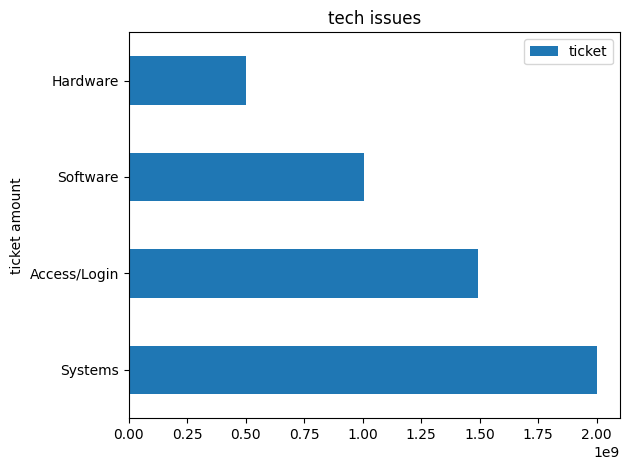

In [25]:
ax = df_quantity_filedagainst.plot(
    kind= "barh",
    y="ticket",
    title="tech issues",
    ylabel="ticket amount"
)

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("filedagainst_bargraph_1stedition.png")

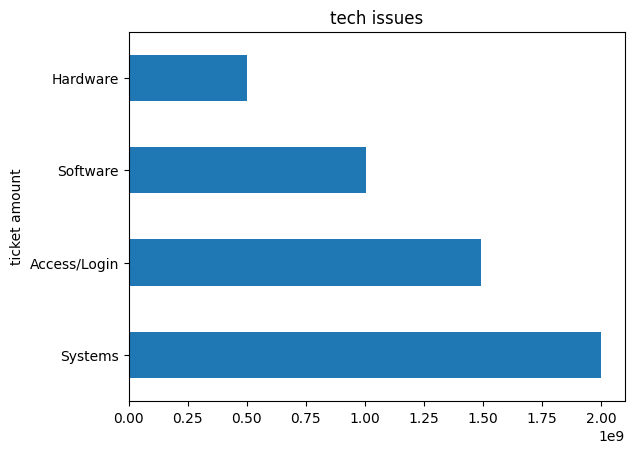

In [26]:
ax = df_quantity_filedagainst.plot(
    kind= "barh",
    y="ticket",
    title="tech issues",
    ylabel="ticket amount"
)

ax.legend().remove()

#fig = ax.get_figure()
#fig.tight_layout()
#fig.savefig("filedagainst_bargraph_2ndedition.png")